In [1]:
from ucimlrepo import fetch_ucirepo 

mice_protein_expression = fetch_ucirepo(id=342) 
  
X = mice_protein_expression.data.features 
y = mice_protein_expression.data.targets 
  
print(mice_protein_expression.metadata) 

print(mice_protein_expression.variables) 

{'uci_id': 342, 'name': 'Mice Protein Expression', 'repository_url': 'https://archive.ics.uci.edu/dataset/342/mice+protein+expression', 'data_url': 'https://archive.ics.uci.edu/static/public/342/data.csv', 'abstract': 'Expression levels of 77 proteins measured in the cerebral cortex of 8 classes of control and Down syndrome mice exposed to context fear conditioning, a task used to assess associative learning.', 'area': 'Biology', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 1080, 'num_features': 80, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': ['MouseID'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Tue Apr 16 2024', 'dataset_doi': '10.24432/C50S3Z', 'creators': ['Clara Higuera', 'Katheleen Gardiner', 'Krzysztof Cios'], 'intro_paper': {'ID': 475, 'type': 'NATIVE', 'title': 'Self-Organizing Feature Maps Identify Proteins Critical

In [8]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns




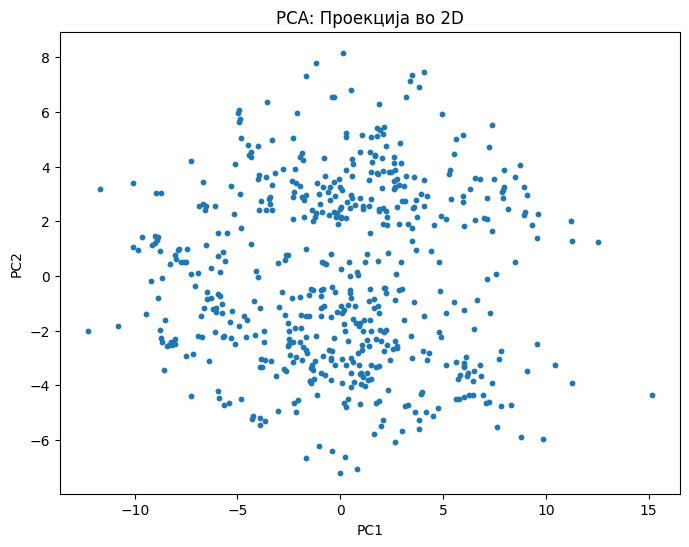

In [5]:

X = X.iloc[:, :-4]
# drop nan values
X = X.dropna()

# z = x-mi / sigma to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
plt.title('PCA: Проекција во 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

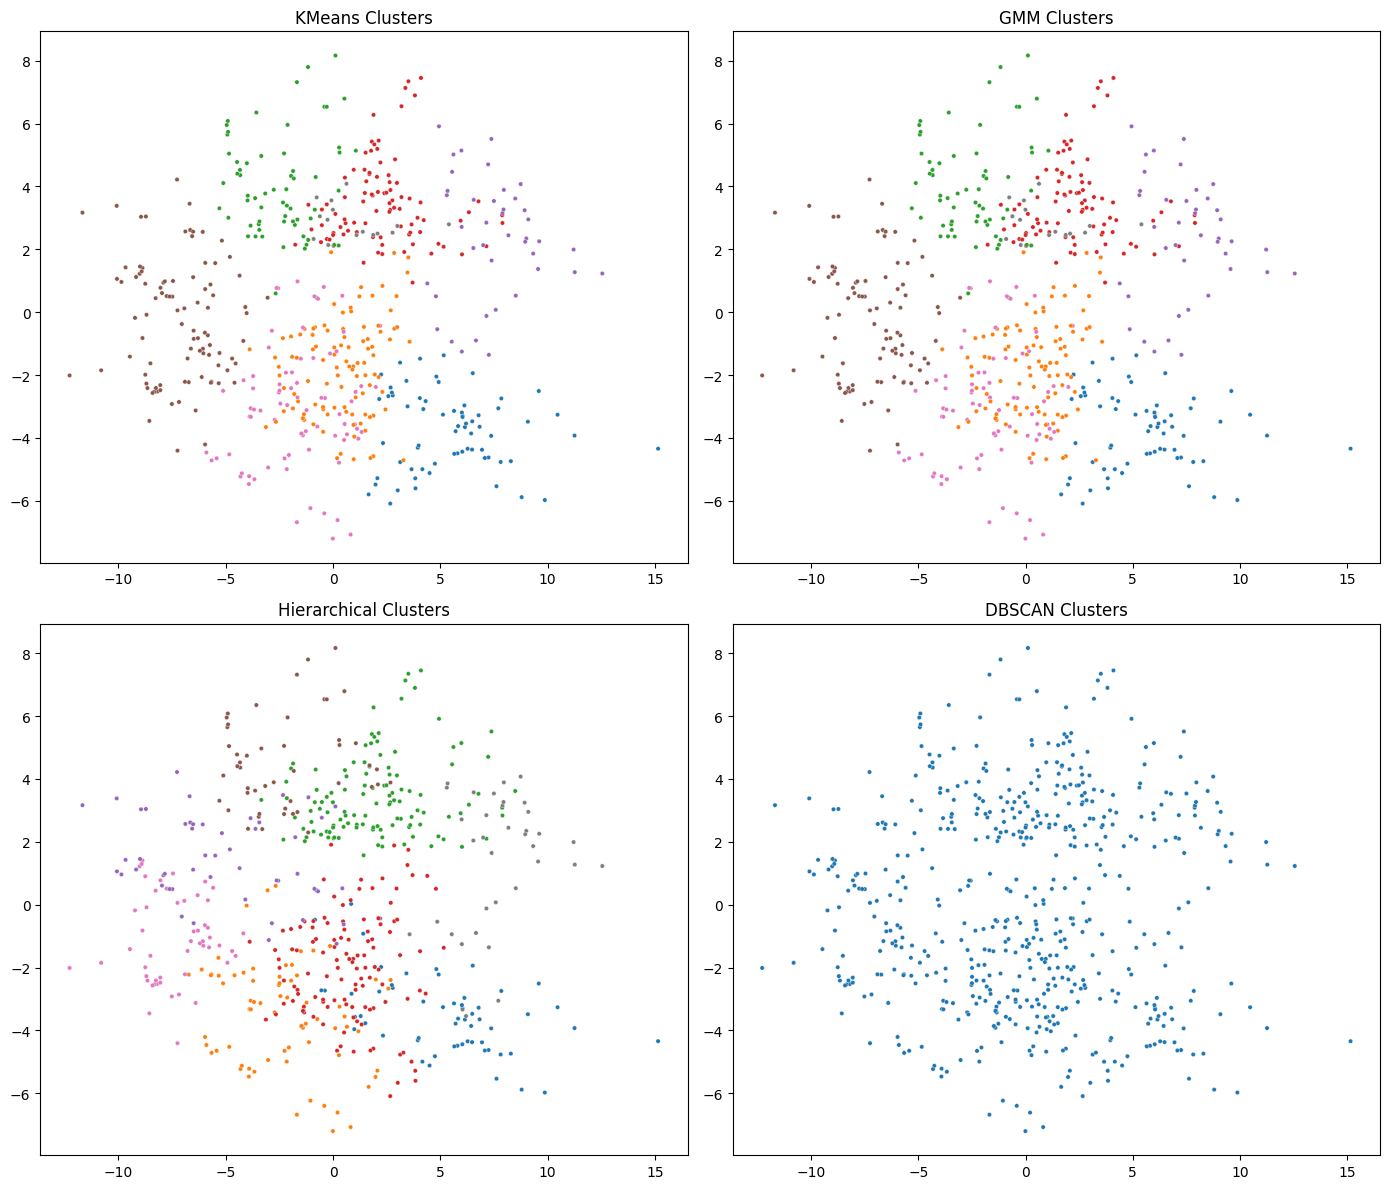

In [ ]:
kmeans = KMeans(n_clusters=8, random_state=0)
kmeans_labels = kmeans.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=8, random_state=0)
gmm_labels = gmm.fit_predict(X_scaled)

hierarchical = AgglomerativeClustering(n_clusters=8)
hierarchical_labels = hierarchical.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='tab10', s=10, legend=False)
plt.title('KMeans Clusters')

plt.subplot(2, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_labels, palette='tab10', s=10, legend=False)
plt.title('GMM Clusters')

plt.subplot(2, 2, 3)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hierarchical_labels, palette='tab10', s=10, legend=False)
plt.title('Hierarchical Clusters')

plt.subplot(2, 2, 4)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='tab10', s=10, legend=False)
plt.title('DBSCAN Clusters')

plt.tight_layout()
plt.show()